# Wound Infection Detection


## 1: Import Libraries and Configuration


In [22]:
# ============================================================================
# Import all required libraries
# ============================================================================

try:
    import json
    import cv2
    import numpy as np
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    from pathlib import Path
    from typing import Dict, List, Tuple
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    from tqdm import tqdm
    import random
    import yaml
    import matplotlib.pyplot as plt
    
    # PyTorch Vision
    import torchvision
    from torchvision.models.detection import maskrcnn_resnet50_fpn
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
    
    print("=" * 60)
    print("✓ All libraries imported successfully!")
    print("=" * 60)
    print(f"PyTorch: {torch.__version__}")
    print(f"NumPy: {np.__version__}")
    print(f"CUDA: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"Device: {torch.cuda.get_device_name(0)}")
    print("=" * 60)
    
except ValueError as e:
    if "numpy.dtype size changed" in str(e):
        print("=" * 60)
        print("❌ Error: numpy/scipy conflict")
        print("=" * 60)
        print("\n🔧 Fix:")
        print("   1. Run in Terminal:")
        print("      pip install --upgrade --force-reinstall numpy scipy")
        print("   2. Or run Part 1 again")
        print("   3. Restart Kernel: Kernel → Restart")
        print("=" * 60)
        raise
    else:
        raise
        
except ImportError as e:
    print("=" * 60)
    print("❌ Import error!")
    print("=" * 60)
    print(f"Error: {e}")
    print("\n🔧 Fix:")
        print("   1. Run Part 1 first (install packages)")
    print("   2. Restart Kernel: Kernel → Restart")
    print("=" * 60)
    raise
# ============================================================================
# Install required packages
# ============================================================================

import sys
import subprocess

def install_package(package):
    """Install a single package with error handling"""
    try:
        print(f"  📦 {package}...", end=" ", flush=True)
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", package],
            capture_output=True,
            text=True,
            check=False
        )
        if result.returncode == 0:
            print("✓")
            return True
        else:
            print("⚠️ (failed - may already be installed)")
            return False
    except Exception as e:
        print(f"❌ Error: {e}")
        return False

print("=" * 60)
print("📦 Installing packages...")
print("=" * 60)

# Install setuptools and wheel first (required for Python 3.13)
print("\n[1/3] Installing setuptools and wheel...")
install_package("setuptools")
install_package("wheel")

# Install numpy and scipy (versions compatible with Python 3.13)
print("\n[2/3] Installing numpy and scipy...")
install_package("numpy>=1.26.0")
install_package("scipy>=1.11.0")

# Install remaining packages (one by one)
print("\n[3/3] Installing remaining packages...")
packages = [
    "torch", "torchvision",
    "opencv-python", "Pillow", "albumentations",
    "pandas", "matplotlib", "seaborn",
    "tqdm", "scikit-learn", "pycocotools",
    "pyyaml", "jupyter", "ipywidgets"
]

for package in packages:
    install_package(package)

print("\n" + "=" * 60)
print("✓ Installation complete!")
print("=" * 60)
print("⚠️ Restart Kernel: Kernel → Restart")
print("=" * 60)



# ============================================================================
# Configuration - you can modify these values
# ============================================================================
# Run from experiments/maskrcnn/: data at ../../data; outputs in ./checkpoints and ./results.
EXPERIMENTS_ROOT = '.'
EXPERIMENT_NAME = 'maskrcnn'

import platform

CONFIG = {
    # Data - paths relative to project root (shared across experiments)
    'data_root': '../../data',  # from experiments/maskrcnn/ -> shared data folder
    'data_mode': 'clean_online_aug',  # clean_only | clean_online_aug | clean_offline_aug (uses annotations_cleaned.json)
    'image_size': [1024, 1024],
    'num_classes': 9,  # 8 target classes + background (set from dataset in Part 3)
    'batch_size': 2,
    # On Windows, use num_workers=0 to avoid multiprocessing issues
    'num_workers': 0 if platform.system() == 'Windows' else 4,
    
    # Training
    'epochs': 50,
    'learning_rate': 0.001,  # SGD linear-scaled for batch_size=2 (~0.02 * 2/16)
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',

    # Early stopping — monitors combined_AP50 (mode=max); no loss-based logic
    'early_stop_patience': 12,
    'early_stop_min_delta': 0.003,  # Small delta for slow AP improvement
    'save_checkpoint_every_n_epochs': 0,

    # Training stability
    'loss_clip_max': 100.0,
    'loss_skip_threshold': 1000.0,
    'skip_invalid_targets': True,

    # Medical Augmentation Strategy Settings
    'use_medical_augmentation': True,  # Enable comprehensive medical augmentation
    'preserve_marker': True,           # Preserve marker geometry (critical for area measurements)
    'intensity': "moderate",           # Augmentation intensity: "light", "moderate", "aggressive"
    
    
    # Splits
    'train_ratio': 0.7,
    'val_ratio': 0.15,
    'test_ratio': 0.15,
    
    # Paths - all experiments under one folder; dataset shared externally
    'checkpoints_dir': 'checkpoints',
    'results_dir': 'results',
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")
print(f"\n✓ Device: {CONFIG['device']}")


✓ All libraries imported successfully!
PyTorch: 2.5.1+cu121
NumPy: 2.3.5
CUDA: True
Device: NVIDIA GeForce RTX 4060 Laptop GPU
📦 Installing packages...

[1/3] Installing setuptools and wheel...
  📦 setuptools... ✓
  📦 wheel... ✓

[2/3] Installing numpy and scipy...
  📦 numpy>=1.26.0... ✓
  📦 scipy>=1.11.0... ✓

[3/3] Installing remaining packages...
  📦 torch... ✓
  📦 torchvision... ✓
  📦 opencv-python... ✓
  📦 Pillow... ✓
  📦 albumentations... ✓
  📦 pandas... ✓
  📦 matplotlib... ✓
  📦 seaborn... ✓
  📦 tqdm... ✓
  📦 scikit-learn... ✓
  📦 pycocotools... ✓
  📦 pyyaml... ✓
  📦 jupyter... ✓
  📦 ipywidgets... ✓

✓ Installation complete!
⚠️ Restart Kernel: Kernel → Restart
Configuration:
  data_root: ../../data
  data_mode: clean_online_aug
  image_size: [1024, 1024]
  num_classes: 9
  batch_size: 2
  num_workers: 0
  epochs: 50
  learning_rate: 0.001
  device: cuda
  early_stop_patience: 12
  early_stop_min_delta: 0.003
  save_checkpoint_every_n_epochs: 0
  loss_clip_max: 100.0
  loss_skip_

## 2: Data Processing


In [17]:
# ============================================================================
# 2.1 CVAT to COCO Converter
# ============================================================================

def convert_cvat_to_coco(data_root: str, output_file: str):
    """Convert CVAT annotations to COCO format"""
    
    # Convert to absolute path - handle relative paths correctly
    current_dir = Path.cwd()
    data_root = Path(data_root)
    
    # Handle relative paths - notebook is in notebooks/ directory
    if not data_root.is_absolute():
        # If path starts with ../, it's already relative to parent
        if str(data_root).startswith('../'):
            data_root = current_dir.parent / data_root
        # If path is relative and we're in notebooks/, go up one level
        elif current_dir.name == 'notebooks':
            data_root = current_dir.parent / data_root
        else:
            data_root = current_dir / data_root
    
    data_root = data_root.resolve()
    
    # Check if project.json exists
    project_file = data_root / "project.json"
    if not project_file.exists():
        print("=" * 60)
        print("❌ Error: project.json file not found!")
        print("=" * 60)
        print(f"Required path: {project_file}")
        print(f"Current path: {current_dir}")
        print(f"data_root: {data_root}")
        print("\n🔧 Fix:")
        print("   1. Ensure 'data' folder exists in project root")
        print("   2. Ensure 'data/project.json' exists")
        print("   3. Or update CONFIG['data_root'] in Part 1")
        print("=" * 60)
        raise FileNotFoundError(f"project.json not found at {project_file}")
    
    # Load project info
    with open(project_file, 'r', encoding='utf-8') as f:
        project_info = json.load(f)
    
    # Create label mapping
    label_map = {label['name']: idx for idx, label in enumerate(project_info['labels'])}
    
    # Initialize COCO structure
    coco_data = {
        'images': [],
        'annotations': [],
        'categories': [{'id': idx, 'name': name} for name, idx in label_map.items()]
    }
    
    image_id = 0
    annotation_id = 0
    
    # Process all tasks
    task_folders = sorted([f for f in data_root.iterdir() if f.is_dir() and f.name.startswith('task_')])
    
    print(f"Processing {len(task_folders)} tasks...")
    
    for task_folder in tqdm(task_folders):
        try:
            # Load annotations
            with open(task_folder / "annotations.json", 'r', encoding='utf-8') as f:
                annotations = json.load(f)
            
            # Get images
            data_dir = task_folder / "data"
            image_files = list(data_dir.glob('*.jpg')) + list(data_dir.glob('*.png'))
            
            for img_file in image_files:
                # Read image to get size
                img = cv2.imread(str(img_file))
                if img is None:
                    continue
                
                h, w = img.shape[:2]
                
                # Add image
                is_infected = '-not-' not in img_file.name.lower()
                coco_data['images'].append({
                    'id': image_id,
                    'file_name': str(img_file.relative_to(data_root)),
                    'width': w,
                    'height': h,
                    'infection_status': is_infected
                })
                
                # Add annotations for this image (first frame)
                if len(annotations) > 0 and 'shapes' in annotations[0]:
                    for shape in annotations[0]['shapes']:
                        if shape['type'] != 'polygon' or shape['label'] not in label_map:
                            continue
                        
                        # Convert polygon points - handle different formats
                        points = shape['points']
                        
                        # Check if points is a list of lists or a flat list
                        if not isinstance(points, list):
                            continue
                        
                        # Handle case where points might be a flat list of floats
                        if len(points) > 0 and isinstance(points[0], (int, float)):
                            # Flat list: [x1, y1, x2, y2, ...]
                            if len(points) % 2 != 0:
                                continue
                            points = [[points[i], points[i+1]] for i in range(0, len(points), 2)]
                        
                        # Ensure points is a list of [x, y] pairs
                        if not all(isinstance(p, (list, tuple)) and len(p) == 2 for p in points):
                            continue
                        
                        polygon = [coord for point in points for coord in point]
                        
                        # Calculate bbox
                        x_coords = [p[0] for p in points]
                        y_coords = [p[1] for p in points]
                        x_min, x_max = min(x_coords), max(x_coords)
                        y_min, y_max = min(y_coords), max(y_coords)
                        bbox = [x_min, y_min, x_max - x_min, y_max - y_min]
                        
                        # Calculate area
                        area = (x_max - x_min) * (y_max - y_min)
                        
                        coco_data['annotations'].append({
                            'id': annotation_id,
                            'image_id': image_id,
                            'category_id': label_map[shape['label']],
                            'segmentation': [polygon],
                            'area': area,
                            'bbox': bbox,
                            'iscrowd': 0
                        })
                        annotation_id += 1
                
                image_id += 1
        
        except Exception as e:
            print(f"Error processing {task_folder.name}: {e}")
    
    # Save COCO file
    Path(output_file).parent.mkdir(parents=True, exist_ok=True)
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(coco_data, f, indent=2)
    
    print(f"\n✓ Done! Saved to {output_file}")
    print(f"✓ Total images: {len(coco_data['images'])}")
    print(f"✓ Total annotations: {len(coco_data['annotations'])}")
    
    return coco_data

print("✓ Converter function defined!")


# ============================================================================
# 2.2 Dataset Splitter
# ============================================================================

def split_dataset(coco_file: str, output_dir: str, train_r=0.7, val_r=0.15, test_r=0.15):
    """Split data into train/val/test"""
    
    with open(coco_file, 'r') as f:
        coco_data = json.load(f)
    
    images = coco_data['images']
    random.shuffle(images)
    
    n = len(images)
    n_train = int(n * train_r)
    n_val = int(n * val_r)
    
    splits = {
        'train': images[:n_train],
        'val': images[n_train:n_train+n_val],
        'test': images[n_train+n_val:]
    }
    
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    for split_name, split_images in splits.items():
        split_ids = {img['id'] for img in split_images}
        split_anns = [ann for ann in coco_data['annotations'] if ann['image_id'] in split_ids]
        
        split_data = {
            'images': split_images,
            'annotations': split_anns,
            'categories': coco_data['categories']
        }
        
        output_file = Path(output_dir) / f'{split_name}.json'
        with open(output_file, 'w') as f:
            json.dump(split_data, f, indent=2)
        
        print(f"✓ {split_name}: {len(split_images)} images, {len(split_anns)} annotations")

print("✓ Splitter function defined!")



✓ Converter function defined!
✓ Splitter function defined!


## 3: Model Building


In [18]:

# ============================================================================
# 3.1 Build Model
# ============================================================================

def build_model(num_classes=9):
    """Build Mask R-CNN (ResNet50-FPN) with COCO-pretrained backbone, custom heads."""
    from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights
    model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)

    # Replace box predictor for num_classes (background + wound classes)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Replace mask predictor
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)

    return model

# Model is built in Part 3 after datasets (num_classes from dataset).

# ============================================================================
# Import Dataset Utilities from pipeline_utils
# ============================================================================

import sys
from pathlib import Path

# Add this directory to path to import pipeline_utils (when run from experiments/maskrcnn/ or notebooks/)
notebooks_dir = Path.cwd()
if notebooks_dir.parent.name == 'experiments':
    # Running from experiments/<name>/: use current folder
    pass
elif notebooks_dir.name != 'notebooks':
    # If we're in project root, go to notebooks/
    if (notebooks_dir / 'notebooks').exists():
        notebooks_dir = notebooks_dir / 'notebooks'
    # If we're in a subdirectory, go up until we find notebooks/
    else:
        parent = notebooks_dir.parent
        while parent != parent.parent:
            if (parent / 'notebooks').exists():
                notebooks_dir = parent / 'notebooks'
                break
            parent = parent.parent

sys.path.insert(0, str(notebooks_dir))

from pipeline_utils import create_dataset, make_dataloaders, collate_fn

print("[OK] Dataset utilities imported from pipeline_utils!")

# ============================================================================
# 3.2 Data source: CLEANED dataset only (Option A - no contaminated offline aug)
# ============================================================================
# DATA_MODE: 'clean_only' | 'clean_online_aug' | 'clean_offline_aug'
# - clean_only: annotations_cleaned.json, no online augmentation
# - clean_online_aug: annotations_cleaned.json + online augmentation (recommended)
# - clean_offline_aug: data/augmented_clean/ (run apply_augmentation_only.py with --from-cleaned first)
# OLD data/augmented/ was generated from unclean annotations - DO NOT USE.

DATA_MODE = CONFIG.get('data_mode', 'clean_online_aug')
_DATA_ROOT = '../../data'
_CLEAN_ANN_FILE = (Path.cwd() / _DATA_ROOT / 'annotations_cleaned.json').resolve()
_SPLIT_SEED   = 42
_TRAIN_RATIO  = 0.82

import json, random as _random

def _split_annotations(ann_path, train_ratio=_TRAIN_RATIO, seed=_SPLIT_SEED):
    """Split a COCO annotation file in-memory into train and val subsets."""
    with open(ann_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    images = data['images'].copy()
    rng = _random.Random(seed)
    rng.shuffle(images)
    n_train = int(len(images) * train_ratio)
    train_ids = {img['id'] for img in images[:n_train]}
    val_ids   = {img['id'] for img in images[n_train:]}
    def _subset(ids):
        return {
            'images':      [i for i in data['images']      if i['id'] in ids],
            'annotations': [a for a in data['annotations'] if a['image_id'] in ids],
            'categories':  data['categories'],
        }
    return _subset(train_ids), _subset(val_ids)

if _CLEAN_ANN_FILE.exists():
    _train_ann, _val_ann = _split_annotations(_CLEAN_ANN_FILE)
else:
    _split_train = (Path.cwd() / _DATA_ROOT / 'splits' / 'train.json').resolve()
    _split_val   = (Path.cwd() / _DATA_ROOT / 'splits' / 'val.json').resolve()
    if _split_train.exists() and _split_val.exists():
        with open(_split_train, 'r', encoding='utf-8') as f: _train_ann = json.load(f)
        with open(_split_val, 'r', encoding='utf-8') as f: _val_ann = json.load(f)
        print('  [INFO] Using data/splits/ (annotations_cleaned.json not found)')
    else:
        raise FileNotFoundError(f'Run clean_dataset.py first. Expected: {_CLEAN_ANN_FILE}')

import tempfile, json as _json
def _save_temp_ann(data, suffix):
    tmp = tempfile.NamedTemporaryFile(mode='w', encoding='utf-8', suffix=suffix, delete=False)
    _json.dump(data, tmp, ensure_ascii=False)
    tmp.close()
    return tmp.name

# Resolve train/val paths and roots per DATA_MODE
_AUG_CLEAN_ROOT = '../../data/augmented_clean'
_OFFLINE_AUG_FILE = (Path.cwd() / _AUG_CLEAN_ROOT / 'annotations_augmented_clean.json').resolve()
if DATA_MODE == 'clean_offline_aug':
    if not _OFFLINE_AUG_FILE.exists():
        raise FileNotFoundError("Offline augmented data not found. Run: cd scripts && python apply_augmentation_only.py")
    _train_ann_path = str(_OFFLINE_AUG_FILE)
    _train_root = _AUG_CLEAN_ROOT
    _val_ann_path = _save_temp_ann(_val_ann, '_val_split.json')
    _val_root = _DATA_ROOT
else:
    _train_ann_path = _save_temp_ann(_train_ann, '_train_split.json')
    _val_ann_path = _save_temp_ann(_val_ann, '_val_split.json')
    _train_root = _val_root = _DATA_ROOT
_use_medical_aug = False if DATA_MODE == 'clean_only' else CONFIG.get('use_medical_augmentation', True)

print(f"  Data mode: {DATA_MODE}")
print(f"  Train root: {_train_root} | Val root: {_val_root}")
print(f"  Split: {len(_train_ann['images'])} train / {len(_val_ann['images'])} val images")
print(f"  Online augmentation: {_use_medical_aug}")

# ============================================================================
# 3.3 Create Datasets and DataLoaders using pipeline_utils
# ============================================================================

train_dataset = create_dataset(
    root=_train_root,
    annotation_file=_train_ann_path,
    train=True,
    image_size=tuple(CONFIG['image_size']),
    use_medical_augmentation=_use_medical_aug,
    preserve_marker=CONFIG.get('preserve_marker', True),
    intensity=CONFIG.get('intensity', 'moderate')
)

val_dataset = create_dataset(
    root=_val_root,
    annotation_file=_val_ann_path,
    train=False,
    image_size=tuple(CONFIG['image_size']),
    use_medical_augmentation=False,
    preserve_marker=True,
    intensity='light'
)

# Create dataloaders using make_dataloaders from pipeline_utils
train_loader, val_loader = make_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers'],
    shuffle_train=True
)

print("✓ Datasets and DataLoaders created!")
print(f"✓ Train samples: {len(train_dataset)}")
print(f"✓ Val samples:   {len(val_dataset)}")

# num_classes from dataset (must match model head; do not use len(coco_json['categories'])+1)
num_classes = train_dataset.num_classes
CONFIG['num_classes'] = num_classes
model = build_model(num_classes=num_classes)
model.to(CONFIG['device'])
print(f"✓ Model built with {num_classes} classes (from dataset)")
print(f"✓ Model moved to {CONFIG['device']}")

# ============================================================================
# 3.4 Setup Optimizer and Scheduler
# ============================================================================

# Optimizer — SGD with momentum/weight-decay (standard for Mask R-CNN fine-tuning)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=CONFIG['learning_rate'], momentum=0.9, weight_decay=0.0005)

# Scheduler — linear warmup for first 5 epochs, then cosine decay for remaining epochs.
# lr_scheduler.step() is called once per epoch in the training loop.
_WARMUP_EPOCHS  = 5
_COSINE_EPOCHS  = CONFIG['epochs'] - _WARMUP_EPOCHS  # 45 with epochs=50

_warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.01, end_factor=1.0, total_iters=_WARMUP_EPOCHS
)
_cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=_COSINE_EPOCHS, eta_min=1e-6
)
lr_scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[_warmup_scheduler, _cosine_scheduler],
    milestones=[_WARMUP_EPOCHS],
)

print("✓ Optimizer and scheduler setup complete!")
print(f"  LR: {CONFIG['learning_rate']}  |  Warmup: {_WARMUP_EPOCHS} epochs → Cosine decay: {_COSINE_EPOCHS} epochs")


[OK] Dataset utilities imported from pipeline_utils!
  Data mode: clean_online_aug
  Train root: ../../data | Val root: ../../data
  Split: 434 train / 96 val images
  Online augmentation: True
loading annotations into memory...
Done (t=0.20s)
creating index...
index created!
Filtering classes. Keeping only: ['ВсяРана', 'Метка для размерности', 'Зона отека вокруг раны', 'Зона гиперемии вокруг', 'Зона некроза', 'Зона грануляций', 'Фибрин', 'Гнойное отделяемое']
  - Class 'ВсяРана' (ID 1) mapped to New ID 1
  - Class 'Метка для размерности' (ID 2) mapped to New ID 2
  - Class 'Зона отека вокруг раны' (ID 3) mapped to New ID 3
  - Class 'Зона гиперемии вокруг' (ID 4) mapped to New ID 4
  - Class 'Зона некроза' (ID 5) mapped to New ID 5
  - Class 'Зона грануляций' (ID 6) mapped to New ID 6
  - Class 'Фибрин' (ID 7) mapped to New ID 7
  - Class 'Гнойное отделяемое' (ID 8) mapped to New ID 8
Total classes for training: 9 (including background)
loading annotations into memory...
Done (t=0.05s

## 4: Start Training



In [19]:
# ============================================================================
# Training Loop (with results accumulation and COCO metrics)
# ============================================================================

import time
from datetime import datetime
from train_model import save_best_checkpoint, save_last_checkpoint, train_one_epoch, validate_one_epoch, evaluate_metrics, generate_report

print("=" * 60)
print("Starting Training")
print("=" * 60)

best_combined_AP50 = 0.0
best_epoch = 0
epochs_without_improve = 0
save_every_n = CONFIG.get('save_checkpoint_every_n_epochs', 0)
base_ds = train_loader.dataset.dataset if hasattr(train_loader.dataset, 'dataset') else train_loader.dataset
class_mapping = getattr(base_ds, 'class_mapping', {})
checkpoints_dir = Path(CONFIG['checkpoints_dir'])
checkpoints_dir.mkdir(exist_ok=True)

train_losses = []
val_losses = []
metrics_per_epoch = []
start_time = time.time()
config_for_report = CONFIG.copy()
config_for_report['lr'] = CONFIG.get('learning_rate', CONFIG.get('lr', 0.0005))

# Early stopping: monitor=combined_AP50, mode=max (higher is better). No loss-based logic.
early_stop_patience = CONFIG.get('early_stop_patience', 0)
early_stop_min_delta = CONFIG.get('early_stop_min_delta', 0.0)

for epoch in range(1, CONFIG['epochs'] + 1):
    print(f"\nEpoch {epoch}/{CONFIG['epochs']}")
    print("-" * 40)
    
    # Train
    train_loss_dict = train_one_epoch(
        model, optimizer, train_loader, CONFIG['device'],
        epoch=epoch,
        loss_clip_max=CONFIG.get('loss_clip_max'),
        loss_skip_threshold=CONFIG.get('loss_skip_threshold'),
        skip_invalid_targets=CONFIG.get('skip_invalid_targets', True)
    )
    train_loss = train_loss_dict.get('total_loss', 0.0)  # Extract total loss
    train_losses.append(train_loss)

    # Validate
    val_loss_dict = validate_one_epoch(
        model, val_loader, CONFIG['device'],
        loss_clip_max=CONFIG.get('loss_clip_max'),
        loss_skip_threshold=CONFIG.get('loss_skip_threshold'),
        skip_invalid_targets=CONFIG.get('skip_invalid_targets', True)
    )
    val_loss = val_loss_dict.get('total_loss', 0.0)  # Extract total loss
    val_losses.append(val_loss)

    # Evaluate COCO metrics (bbox_AP50, segm_AP50, etc.)
    print("Evaluating metrics...")
    try:
        metrics = evaluate_metrics(model, val_loader, torch.device(CONFIG['device']))
        metrics_per_epoch.append(metrics)
    except Exception as e:
        print(f"  [WARNING] Metrics evaluation failed: {e}")
        metrics_per_epoch.append({})

    # Step scheduler
    lr_scheduler.step()
    
    # Print stats
    print(f"\nTrain Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Best model selection by combined_AP50 (higher is better)
    combined_AP50 = metrics.get('combined_AP50', 0.0) if metrics else 0.0
    bbox_AP50 = metrics.get('bbox_AP50', 0.0) if metrics else 0.0
    segm_AP50 = metrics.get('segm_AP50', bbox_AP50) if metrics else bbox_AP50
    metrics_with_loss = dict(metrics) if metrics else {}
    metrics_with_loss['val_loss'] = val_loss
    print(f"combined_AP50: {combined_AP50:.4f} | bbox_AP50: {bbox_AP50:.4f} | segm_AP50: {segm_AP50:.4f}")
    
    # Best model: save on any improvement. Early stop: no save for patience epochs.
    is_best = combined_AP50 > best_combined_AP50
    # Always save on epoch 1 so best_model.pth exists even if combined_AP50 is 0 (eval failed / no preds)
    if is_best or epoch == 1:
        if is_best:
            best_combined_AP50 = combined_AP50
            best_epoch = epoch
            epochs_without_improve = 0
            print(f"✓ NEW BEST! combined_AP50: {best_combined_AP50:.4f}")
        elif epoch == 1:
            best_combined_AP50 = combined_AP50
            best_epoch = epoch
            print(f"  → First epoch: saving best_model.pth (combined_AP50={combined_AP50:.4f})")
        save_best_checkpoint(
            model, epoch=epoch, best_combined_AP50=best_combined_AP50,
            bbox_AP50=bbox_AP50, segm_AP50=segm_AP50,
            config=CONFIG.copy(), class_mapping=class_mapping,
            output_dir=checkpoints_dir, filename='best_model.pth'
        )
    else:
        epochs_without_improve += 1
    
    # Always save last checkpoint for resume
    save_last_checkpoint(
        model, optimizer, lr_scheduler, epoch=epoch, metrics=metrics_with_loss,
        output_dir=checkpoints_dir, filename='last_checkpoint.pth', scaler=None
    )
    
    # Optional: save debug checkpoint every N epochs (set save_checkpoint_every_n_epochs in CONFIG)
    if save_every_n > 0 and epoch % save_every_n == 0:
        torch.save({'model': model.state_dict(), 'epoch': epoch, 'metrics': metrics_with_loss},
                   checkpoints_dir / f'checkpoint_epoch_{epoch}.pth')
        print(f"  → Debug checkpoint saved: checkpoint_epoch_{epoch}.pth")

    if early_stop_patience > 0 and epochs_without_improve >= early_stop_patience:
        print(f"Early stopping triggered after {epochs_without_improve} epochs without improvement.")
        break

training_time = time.time() - start_time

# Build results dict and save training_results.json + training_report.md
results = {
    'config': config_for_report,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'metrics_per_epoch': metrics_per_epoch,
    'best_metric': best_combined_AP50,
    'best_epoch': best_epoch,
    'best_metric_name': 'combined_AP50',
    'training_start': datetime.fromtimestamp(start_time).isoformat(),
    'training_end': datetime.now().isoformat(),
    'training_time': training_time,
    'device': str(CONFIG['device']),
    'num_classes': CONFIG['num_classes'],
    'final_metrics': metrics_per_epoch[-1] if metrics_per_epoch else {},
}

results_file = checkpoints_dir / 'training_results.json'
with open(results_file, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, default=str)
print(f"\n[OK] Results saved to: {results_file}")

report_file = checkpoints_dir / 'training_report.md'
generate_report(results, report_file)
print(f"[OK] Report saved to: {report_file}")

print("\n" + "=" * 60)
print("Training completed!")
print(f"Best combined_AP50: {best_combined_AP50:.4f} (epoch {best_epoch})")
print(f"Total time: {training_time:.2f}s ({training_time/60:.2f} min)")
print("=" * 60)


Starting Training

Epoch 1/50
----------------------------------------
Epoch: [1] [0/217] Loss: 6.5483
Epoch: [1] [10/217] Loss: 4.0245
Epoch: [1] [20/217] Loss: 5.0646
Epoch: [1] [30/217] Loss: 4.0949
Epoch: [1] [40/217] Loss: 5.6196
Epoch: [1] [50/217] Loss: 5.3724
Epoch: [1] [60/217] Loss: 6.0696
Epoch: [1] [70/217] Loss: 5.6215
Epoch: [1] [80/217] Loss: 6.1937
Epoch: [1] [90/217] Loss: 7.7334
Epoch: [1] [100/217] Loss: 7.6217
Epoch: [1] [110/217] Loss: 4.4450
Epoch: [1] [120/217] Loss: 4.3490
Epoch: [1] [130/217] Loss: 7.7835
Epoch: [1] [140/217] Loss: 6.8081
Epoch: [1] [150/217] Loss: 3.6738
Epoch: [1] [160/217] Loss: 6.7630
Epoch: [1] [170/217] Loss: 4.7246
Epoch: [1] [180/217] Loss: 4.3816
Epoch: [1] [190/217] Loss: 5.9679
Epoch: [1] [200/217] Loss: 6.3634
Epoch: [1] [210/217] Loss: 4.8344
Evaluating metrics...
Using COCO evaluator...
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
D

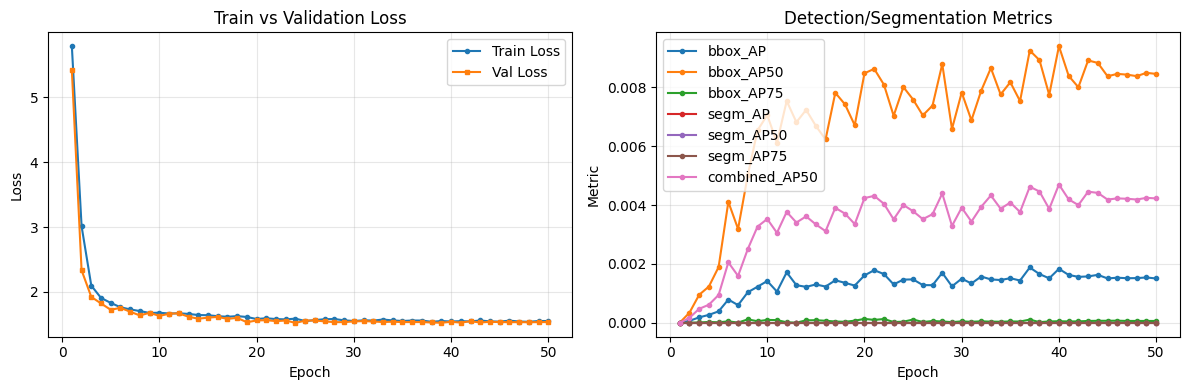

In [20]:
# ============================================================================
# Plot training curves (run after training; uses `results` from previous cell)
# ============================================================================

if 'results' in dir() and results.get('train_losses'):
    fig, axes = plt.subplots(1, 2 if results.get('metrics_per_epoch') else 1, figsize=(12, 4))
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    epochs_range = range(1, len(results['train_losses']) + 1)
    axes[0].plot(epochs_range, results['train_losses'], label='Train Loss', marker='o', markersize=3)
    axes[0].plot(epochs_range, results['val_losses'], label='Val Loss', marker='s', markersize=3)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Train vs Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    if results.get('metrics_per_epoch') and len(results['metrics_per_epoch']) == len(results['train_losses']):
        metric_keys = [k for k in results['metrics_per_epoch'][0] if isinstance(results['metrics_per_epoch'][0].get(k), (int, float))]
        for k in metric_keys:
            vals = [m.get(k, 0) for m in results['metrics_per_epoch']]
            axes[1].plot(epochs_range, vals, label=k, marker='o', markersize=3)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Metric')
        axes[1].set_title('Detection/Segmentation Metrics')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Run the training cell above first to get `results`.")

## 5: Prediction


✓ Helper functions defined!
✓ Prediction function defined!
✓ Visualization function defined!
Loading model from: checkpoints\best_model.pth
✓ Model loaded successfully!
  - Epoch: 40
  - combined_AP50: 0.0047

Wound Detection - Prediction

Image: data/task_0/data/task_0_image_001.jpg
Confidence Threshold: 0.3

Predicting...

Results:
----------------------------------------
Detections: 4
Wound Area: 25.060018050541522 cm²
Infection: NO (confidence: 0.00)

Findings:
  edema: ✗
  hyperemia: ✗
  necrosis: ✗
  granulation: ✗
  fibrin: ✗

Visualizing...


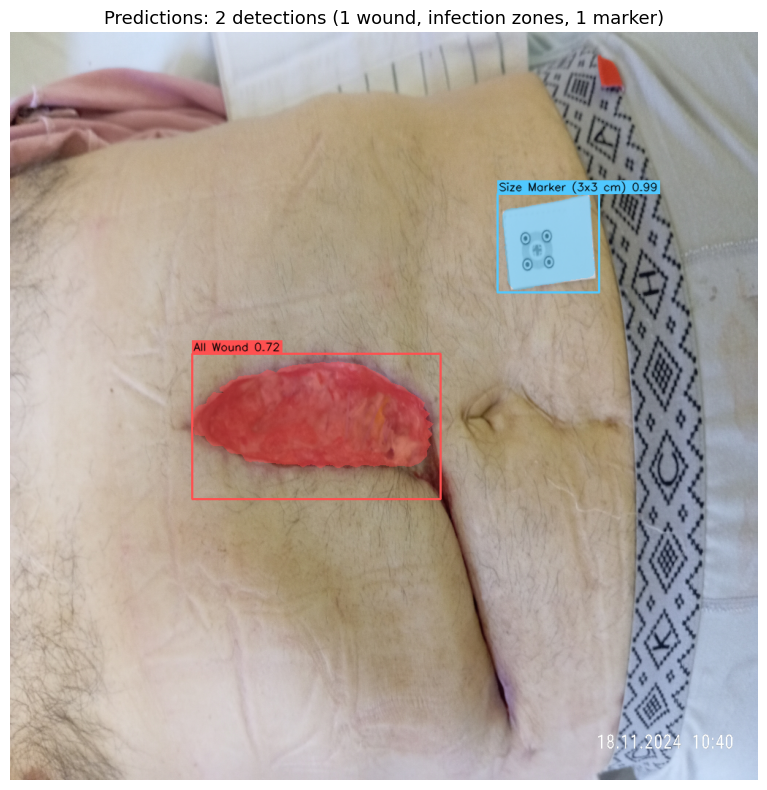


✓ Result saved: results\task_0_image_001_result.json


In [21]:
# ============================================================================
# 5.1 Helper Functions for Prediction
# ============================================================================

def calculate_wound_area(predictions, marker_class_id=2, marker_size_cm=3.0):
    """Compute wound area using 3×3 cm reference marker"""
    
    labels = predictions['labels'].cpu().numpy()
    masks = predictions['masks'].cpu().numpy()
    
    # Find marker
    marker_idx = np.where(labels == marker_class_id)[0]
    
    if len(marker_idx) == 0:
        return None, None
    
    # Get marker mask
    marker_mask = masks[marker_idx[0]][0] > 0.5
    marker_area_pixels = marker_mask.sum()
    
    if marker_area_pixels == 0:
        return None, None
    
    # Calculate pixel to cm ratio
    pixel_to_cm = marker_size_cm / np.sqrt(marker_area_pixels)
    
    # Find wound (class 0)
    wound_idx = np.where(labels == 1)[0]
    
    if len(wound_idx) == 0:
        return None, pixel_to_cm
    
    # Get wound mask
    wound_mask = masks[wound_idx[0]][0] > 0.5
    wound_area_pixels = wound_mask.sum()
    
    # Convert to cm²
    wound_area_cm2 = wound_area_pixels * (pixel_to_cm ** 2)
    
    return wound_area_cm2, pixel_to_cm


def detect_infection(predictions, infection_classes=[3, 4, 5, 7, 8]):
    """Detect infection from present classes"""
    
    labels = predictions['labels'].cpu().numpy()
    scores = predictions['scores'].cpu().numpy()
    
    # Check for infection indicators
    infection_detections = []
    
    for label, score in zip(labels, scores):
        if label in infection_classes:
            infection_detections.append(float(score))
    
    if len(infection_detections) > 0:
        return True, np.mean(infection_detections)
    
    return False, 0.0

print("✓ Helper functions defined!")

# ============================================================================
# 5.2 Prediction Function
# ============================================================================

@torch.no_grad()
def predict_image(image_path: str, model, device, conf_threshold=0.5):
    """Predict on a single image"""
    
    model.eval()
    
    # Convert to absolute path if needed
    img_path = Path(image_path)
    if not img_path.is_absolute():
        current_dir = Path.cwd()
        if current_dir.name == 'maskrcnn' and current_dir.parent.name == 'experiments':
            project_root = current_dir.parent.parent
        elif current_dir.name == 'notebooks':
            project_root = current_dir.parent
        else:
            project_root = current_dir
        candidate = project_root / image_path
        img_path = candidate if candidate.exists() else (current_dir / image_path)
    
    # Load image
    image = cv2.imread(str(img_path))
    
    # Check if image loaded successfully
    if image is None:
        raise FileNotFoundError(f"Could not load image from: {img_path}\nPlease check the path and make sure the image exists.")
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Resize
    image_resized = cv2.resize(image_rgb, tuple(CONFIG['image_size']))
    
    # To tensor
    image_tensor = torch.from_numpy(image_resized).permute(2, 0, 1).float() / 255.0
    
    # Normalize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image_tensor = (image_tensor - mean) / std
    
    # Predict
    predictions = model([image_tensor.to(device)])[0]
    
    # Filter by confidence
    keep = predictions['scores'] >= conf_threshold
    filtered = {
        'boxes': predictions['boxes'][keep],
        'labels': predictions['labels'][keep],
        'scores': predictions['scores'][keep],
        'masks': predictions['masks'][keep]
    }
    
    # Calculate wound area
    wound_area, _ = calculate_wound_area(filtered)
    
    # Detect infection
    has_infection, infection_conf = detect_infection(filtered)
    
    # Build result
    result = {
        'image_path': image_path,
        'num_detections': len(filtered['labels']),
        'wound_area_cm2': float(wound_area) if wound_area else None,
        'has_infection': has_infection,
        'infection_confidence': float(infection_conf),
        'findings': {
            'edema': 3 in filtered['labels'].cpu().numpy(),
            'hyperemia': 4 in filtered['labels'].cpu().numpy(),
            'necrosis': 5 in filtered['labels'].cpu().numpy(),
            'granulation': 6 in filtered['labels'].cpu().numpy(),
            'fibrin': 7 in filtered['labels'].cpu().numpy(),
        }
    }
    
    return result, filtered

print("✓ Prediction function defined!")

# ============================================================================
# 5.3 Visualization Function
# ============================================================================

# Fixed class colors: each training class ID (1-8) gets a distinct, readable color.
# Using a fixed palette avoids random colors changing on every call.
_CLASS_COLORS = {
    1: (255, 80,  80),   # AllWound       — red
    2: (80,  200, 255),  # SizeMarker     — cyan
    3: (255, 220, 60),   # Edema          — yellow
    4: (255, 140, 0),    # Hyperemia      — orange
    5: (160, 32,  240),  # Necrosis       — purple
    6: (50,  205, 50),   # Granulation    — green
    7: (255, 105, 180),  # Fibrin         — pink
    8: (180, 180, 60),   # Pus            — olive
}
_CLASS_NAMES = {
    1: 'All Wound',
    2: 'Size Marker (3x3 cm)',
    3: 'Edema Zone',
    4: 'Hyperemia Zone',
    5: 'Necrosis Zone',
    6: 'Granulation Zone',
    7: 'Fibrin',
    8: 'Purulent Discharge',
}


def visualize_prediction(image_path: str, predictions):
    """Overlay segmentation masks, bounding boxes and class labels on the original image.

    The original image is loaded fresh from disk (not from any normalized tensor),
    so the background is always the real clinical photo.
    Masks are blended per-pixel only inside each mask region — the background is
    never darkened regardless of how many detections there are.
    """
    # Resolve path relative to project root when running from experiments/maskrcnn/
    img_path = Path(image_path)
    if not img_path.is_absolute():
        current_dir = Path.cwd()
        if current_dir.name == 'maskrcnn' and current_dir.parent.name == 'experiments':
            project_root = current_dir.parent.parent
        elif current_dir.name == 'notebooks':
            project_root = current_dir.parent
        else:
            project_root = current_dir
        candidate = project_root / image_path
        img_path = candidate if candidate.exists() else (current_dir / image_path)

    image = cv2.imread(str(img_path))
    if image is None:
        print(f"Warning: could not load image from: {img_path}")
        return
    image = cv2.resize(image, tuple(CONFIG['image_size']))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32)

    masks  = predictions['masks'].cpu().numpy()
    labels = predictions['labels'].cpu().numpy()
    scores = predictions['scores'].cpu().numpy()
    boxes  = predictions['boxes'].cpu().numpy() if 'boxes' in predictions else np.zeros((len(labels), 4))

    # --- Filter: one box for main wound (highest score), one per infection zone, one for marker ---
    WOUND_CLASS = 1
    MARKER_CLASS = 2
    INFECTION_CLASSES = (3, 4, 5, 6, 7, 8)  # Edema, Hyperemia, Necrosis, Granulation, Fibrin, Purulent
    keep_idx = []
    wound_scores = np.where(labels == WOUND_CLASS)[0]
    if len(wound_scores) > 0:
        best_wound = wound_scores[np.argmax(scores[wound_scores])]
        keep_idx.append(best_wound)
    for cid in INFECTION_CLASSES:
        idx = np.where(labels == cid)[0]
        if len(idx) > 0:
            keep_idx.append(idx[np.argmax(scores[idx])])
    marker_idx = np.where(labels == MARKER_CLASS)[0]
    if len(marker_idx) > 0:
        keep_idx.append(marker_idx[np.argmax(scores[marker_idx])])
    keep_idx = sorted(set(keep_idx))
    masks  = masks[keep_idx]
    labels = labels[keep_idx]
    scores = scores[keep_idx]
    boxes  = boxes[keep_idx] if len(boxes) > 0 else np.zeros((len(keep_idx), 4))

    # --- Mask overlay (per-pixel alpha blend inside mask only) ---
    # Bug fix: old code called cv2.addWeighted in a loop which multiplied the
    # background by 0.7 each iteration → with 7 detections the background became
    # 0.7^7 ≈ 8% of original brightness (effectively black).
    # Fix: blend only inside the mask region; background pixels are untouched.
    overlay = image_rgb.copy()
    for mask, label in zip(masks, labels):
        binary = (mask[0] > 0.5)
        color  = np.array(_CLASS_COLORS.get(int(label), (200, 200, 200)), dtype=np.float32)
        overlay[binary] = overlay[binary] * 0.55 + color * 0.45

    result_img = np.clip(overlay, 0, 255).astype(np.uint8)

    # --- Bounding boxes and labels ---
    for i, (box, label, score) in enumerate(zip(boxes, labels, scores)):
        x1, y1, x2, y2 = map(int, box)
        color_u8 = _CLASS_COLORS.get(int(label), (200, 200, 200))
        cv2.rectangle(result_img, (x1, y1), (x2, y2), color_u8, 2)
        class_name = _CLASS_NAMES.get(int(label), f'cls{label}')
        text = f"{class_name} {score:.2f}"
        (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(result_img, (x1, y1 - th - 6), (x1 + tw + 4, y1), color_u8, -1)
        cv2.putText(result_img, text, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)

    plt.figure(figsize=(12, 8))
    plt.imshow(result_img)
    plt.axis('off')
    n_display = len(labels)
    plt.title(f"Predictions: {n_display} detections (1 wound, infection zones, 1 marker)", fontsize=13)
    plt.tight_layout()
    plt.show()

print("✓ Visualization function defined!")


# ============================================================================
# Load Model and Predict
# ============================================================================

# Choose checkpoint: 'best' (best_model.pth by combined_AP50) or specific epoch (e.g. 15).
# best_model.pth is selected by highest combined_AP50; no loss-based selection.
# Use int (e.g. 15) only if save_checkpoint_every_n_epochs was enabled and that epoch was saved.
INFERENCE_CHECKPOINT = 'best'  # 'best' or int (e.g. 15)

if INFERENCE_CHECKPOINT == 'best':
    model_path = Path(CONFIG['checkpoints_dir']) / 'best_model.pth'
else:
    model_path = Path(CONFIG['checkpoints_dir']) / f'checkpoint_epoch_{INFERENCE_CHECKPOINT}.pth'
    if not model_path.exists():
        fallback = Path(CONFIG['checkpoints_dir']) / 'best_model.pth'
        if fallback.exists():
            print(f"⚠️ checkpoint_epoch_{INFERENCE_CHECKPOINT}.pth not found (enable save_checkpoint_every_n_epochs to save). Using best_model.pth")
            model_path = fallback

# Check prerequisites: model (from Part 3 or build here) and checkpoint (from Part 4)
model_ready = False
if 'model' not in globals():
    # Build model for inference when Part 3/4 not run (e.g. kernel restarted). num_classes must match dataset used for training.
    try:
        from train_model import build_model
        import torch
        _ds = globals().get('train_dataset')
        _base = _ds.dataset if _ds is not None and isinstance(_ds, torch.utils.data.Subset) else _ds
        _nc = getattr(_base, 'num_classes', None) if _base is not None else None
        if _nc is None:
            _nc = CONFIG['num_classes']
        model = build_model(num_classes=_nc)
        model.to(CONFIG['device'])
        print("✓ Model built from train_model (Part 3/4 not run)")
    except NameError:
        print("⚠️ CONFIG not defined! Please run Part 1 (Import Libraries and Configuration) first.")
    except Exception as e:
        print(f"⚠️ Could not build model: {e}")

if 'model' in globals():
    if not model_path.exists():
        print("⚠️ Model checkpoint not found! Please train the model first (Part 4: Start Training)")
        print(f"   Expected path: {model_path.resolve()}")
    else:
        print(f"Loading model from: {model_path}")
        checkpoint = torch.load(model_path, map_location=CONFIG['device'], weights_only=False)
        model_state = checkpoint.get('model') or checkpoint.get('model_state_dict')
        model.load_state_dict(model_state)
        model.eval()
        print("✓ Model loaded successfully!")
        if 'epoch' in checkpoint:
            print(f"  - Epoch: {checkpoint['epoch']}")
        if 'best_combined_AP50' in checkpoint:
            print(f"  - combined_AP50: {checkpoint['best_combined_AP50']:.4f}")
        elif 'val_loss' in checkpoint:
            print(f"  - Val loss: {checkpoint['val_loss']:.4f}")
        model_ready = True

if model_ready:
    # Change path to image you want to predict on
    image_path = 'data/task_0/data/task_0_image_001.jpg'  # Relative to project root (or use absolute path)

    # Lower confidence threshold for better recall (0.3 instead of 0.5)
    CONF_THRESHOLD = 0.3

    print("\n" + "=" * 60)
    print("Wound Detection - Prediction")
    print("=" * 60)
    print(f"\nImage: {image_path}")
    print(f"Confidence Threshold: {CONF_THRESHOLD}")

    # Predict with lower threshold
    print("\nPredicting...")
    result, predictions = predict_image(image_path, model, CONFIG['device'], conf_threshold=CONF_THRESHOLD)

    # Print result
    print("\nResults:")
    print("-" * 40)
    print(f"Detections: {result['num_detections']}")
    print(f"Wound Area: {result['wound_area_cm2']} cm²" if result['wound_area_cm2'] else "Wound Area: N/A")
    print(f"Infection: {'YES' if result['has_infection'] else 'NO'} (confidence: {result['infection_confidence']:.2f})")
    print("\nFindings:")
    for finding, present in result['findings'].items():
        print(f"  {finding}: {'✓' if present else '✗'}")

    # Visualize
    print("\nVisualizing...")
    visualize_prediction(image_path, predictions)

    # Save result
    output_dir = Path(CONFIG['results_dir'])
    output_dir.mkdir(exist_ok=True)

    result_file = output_dir / f"{Path(image_path).stem}_result.json"
    with open(result_file, 'w') as f:
        json.dump(result, f, indent=2)
    print(f"\n✓ Result saved: {result_file}")